In [1]:
!pip install torch torchvision scikit-learn matplotlib pandas numpy tqdm --quiet
!pip install timm --quiet

## SECTION 1 — IMPORTS & CONFIGURATION

In [18]:
import os, json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Circle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score)
from PIL import Image
from tqdm import tqdm
import timm

from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix
import torch, torch.nn.functional as F
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {DEVICE}")
# KAGGLE PATHS
SMAP_ROOT   = "/kaggle/input/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl"
SPEED_ROOT  = "/kaggle/input/datasets/qingch/speedplus/speedplusv2"
SMAP_DATA   = os.path.join(SMAP_ROOT,  "data", "data")
SMAP_LABELS = os.path.join(SMAP_ROOT,  "labeled_anomalies.csv")
SPEED_SYNTH = os.path.join(SPEED_ROOT, "synthetic")
SPEED_CAM   = os.path.join(SPEED_ROOT, "camera.json")

 Device: cuda


## SECTION 2 — DATA LOADING

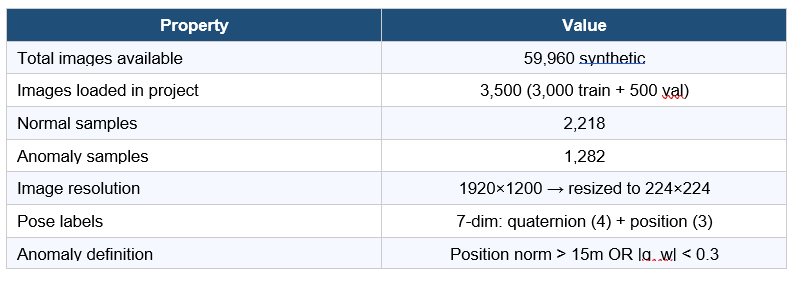

In [3]:
# 2A: Loading SMAP Telemetry channels
def load_smap(data_dir, labels_csv, max_channels=20):
    """Load NASA SMAP telemetry channels + anomaly labels."""
    labels_df = pd.read_csv(labels_csv)
    print(f"[SMAP] Columns found : {list(labels_df.columns)}")
    print(f"[SMAP] Total rows    : {len(labels_df)}")
    print(labels_df.head(3).to_string()); print()

    col_lower = {c.lower().strip(): c for c in labels_df.columns}
    chan_col  = (col_lower.get("chan_id") or col_lower.get("channel_id")
                 or col_lower.get("channel") or labels_df.columns[0])
    anom_col  = (col_lower.get("anomaly_sequences") or col_lower.get("anomalies")
                 or col_lower.get("anomaly_sequence") or None)
    print(f"[SMAP] chan_id column : {chan_col}")
    print(f"[SMAP] anomaly column : {anom_col}\n")

    channel_data, anomaly_labels = {}, {}
    loaded = 0
    for _, row in labels_df.iterrows():
        if loaded >= max_channels: break
        chan_id = str(row[chan_col]).strip()
        train_f = os.path.join(data_dir, "train", f"{chan_id}.npy")
        test_f  = os.path.join(data_dir, "test",  f"{chan_id}.npy")
        if not (os.path.exists(train_f) and os.path.exists(test_f)): continue
        train_arr = np.load(train_f); test_arr = np.load(test_f)
        full_arr  = np.vstack([train_arr, test_arr]).astype(np.float32)
        T_train   = len(train_arr); T = len(full_arr)
        y = np.zeros(T, dtype=np.int32)
        if anom_col and pd.notna(row.get(anom_col, np.nan)):
            try:
                seqs = eval(str(row[anom_col]))
                for seq in seqs:
                    s = T_train + int(seq[0]); e = T_train + int(seq[1])
                    y[s:min(e+1, T)] = 1
            except Exception: pass
        channel_data[chan_id] = full_arr; anomaly_labels[chan_id] = y
        loaded += 1

    total_pts  = sum(len(v) for v in anomaly_labels.values())
    total_anom = sum(np.sum(v) for v in anomaly_labels.values())
    print(f"[SMAP] Loaded    : {len(channel_data)} channels")
    print(f"[SMAP] Total pts : {total_pts}")
    print(f"[SMAP] Anomaly % : {100*total_anom/max(total_pts,1):.2f}%\n")
    return channel_data, anomaly_labels

In [4]:
# 2B: Load SPEEDPlus Satellite Images
def load_speedplus(synth_dir, cam_path, n_train=3000, n_val=500):
    """Load SPEEDPlus satellite images + pose-based anomaly labels."""
    if os.path.exists(cam_path):
        with open(cam_path) as f: cam = json.load(f)
        print(f"[SPEED+] Camera keys: {list(cam.keys())}")

    def parse_json(fpath):
        if not os.path.exists(fpath):
            print(f"  ⚠ Not found: {fpath}"); return []
        with open(fpath) as f: return json.load(f)

    train_data = parse_json(os.path.join(synth_dir, "train.json"))
    val_data   = parse_json(os.path.join(synth_dir, "validation.json"))
    print(f"[SPEED+] train entries : {len(train_data)}")
    print(f"[SPEED+] val   entries : {len(val_data)}")

    if not train_data:
        return [], np.array([]), np.array([])

    sample = train_data[0]
    print(f"[SPEED+] Entry keys    : {list(sample.keys())}")
    q_key = next((k for k in sample if isinstance(sample[k], list) and len(sample[k])==4), None)
    r_key = next((k for k in sample if isinstance(sample[k], list) and len(sample[k])==3), None)
    f_key = next((k for k in sample if isinstance(sample[k], str)
                  and ("/" in sample[k] or "." in sample[k])), None)
    print(f"[SPEED+] quaternion key: {q_key}")
    print(f"[SPEED+] position  key : {r_key}")
    print(f"[SPEED+] filename  key : {f_key}\n")

    def parse_entries(entries, base_dir, limit):
        imgs, poses, labels = [], [], []; skipped = 0
        for entry in entries[:limit]:
            fpath = os.path.join(base_dir, "images", entry.get(f_key, ""))
            if not os.path.exists(fpath): skipped += 1; continue
            q = np.array(entry[q_key], dtype=np.float32)
            r = np.array(entry[r_key], dtype=np.float32)
            label = int(np.linalg.norm(r) > 15.0 or abs(q[-1]) < 0.3)
            imgs.append(fpath); poses.append(np.concatenate([q, r])); labels.append(label)
        if skipped: print(f"  ⚠ Skipped {skipped} entries (images not found)")
        return imgs, np.array(poses, dtype=np.float32), np.array(labels, dtype=np.int32)

    tr_imgs, tr_poses, tr_labels = parse_entries(train_data, synth_dir, n_train)
    va_imgs, va_poses, va_labels = parse_entries(val_data,   synth_dir, n_val)
    all_imgs   = tr_imgs + va_imgs
    all_poses  = np.vstack([tr_poses, va_poses]) if len(tr_poses) else np.zeros((0,7))
    all_labels = np.concatenate([tr_labels, va_labels]) if len(tr_labels) else np.zeros(0)
    print(f"[SPEED+] Total loaded : {len(all_imgs)}")
    print(f"[SPEED+] Normal       : {int(np.sum(all_labels==0))}")
    print(f"[SPEED+] Anomaly      : {int(np.sum(all_labels==1))}\n")
    return all_imgs, all_poses, all_labels

In [5]:
# Dataset Class
class SpeedPlusDataset(Dataset):
    """PyTorch Dataset for SPEEDPlus satellite images."""
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_paths, labels, augment=False):
        self.paths = img_paths; self.labels = labels
        base = [transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(self.MEAN, self.STD)]
        aug  = [transforms.Resize((256, 256)),
                transforms.RandomCrop(224),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.2, 0.2, 0.1),
                transforms.ToTensor(),
                transforms.Normalize(self.MEAN, self.STD)]
        self.transform = transforms.Compose(aug if augment else base)

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), int(self.labels[i])

## SECTION 3 — CNN + TRANSFORMER FEATURE EXTRACTION  
####  Model           Type               Pretrained On   Out-dim

####  ResNet50        CNN (residual)     ImageNet-1k     128
####  EfficientNetB0  CNN (compound)     ImageNet-1k     128
####  ViT-B/16        Transformer        ImageNet-21k    128
####                                     Averaged → fused 128

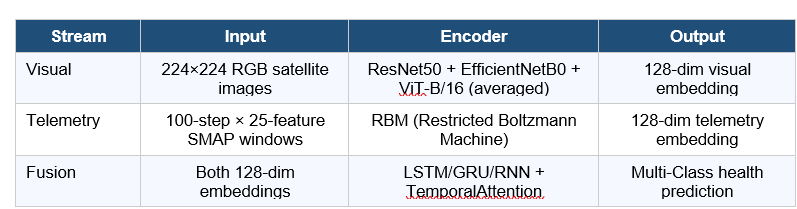

In [6]:
class ResNet50Extractor(nn.Module):
    """ResNet50 — ALL layers FROZEN (feature extraction only)."""
    def __init__(self, out_dim=128):
        super().__init__()
        b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for p in b.parameters(): p.requires_grad = False
        self.backbone  = nn.Sequential(*list(b.children())[:-1])
        self.projector = nn.Sequential(
            nn.Flatten(), nn.Linear(2048, out_dim), nn.ReLU())
    def forward(self, x): return self.projector(self.backbone(x))


class EfficientNetB0Extractor(nn.Module):
    """EfficientNetB0 — ALL layers FROZEN (feature extraction only)."""
    def __init__(self, out_dim=128):
        super().__init__()
        b = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for p in b.parameters(): p.requires_grad = False
        self.backbone  = nn.Sequential(b.features, b.avgpool)
        self.projector = nn.Sequential(
            nn.Flatten(), nn.Linear(1280, out_dim), nn.ReLU())
    def forward(self, x): return self.projector(self.backbone(x))


class ViTExtractor(nn.Module):
    """
    Vision Transformer ViT-B/16 — ALL layers FROZEN.
    Splits 224×224 image into 196 patches of 16×16 pixels.
    Uses multi-head self-attention (NO convolutions at all).
    CLS token (768-dim) → projected to 128-dim embedding.
    Captures GLOBAL context across the whole satellite frame.
    """
    def __init__(self, out_dim=128):
        super().__init__()
        vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0        # removes head → outputs 768-dim CLS token
        )
        for p in vit.parameters(): p.requires_grad = False
        self.vit = vit
        self.projector = nn.Sequential(
            nn.Linear(768, 256), nn.ReLU(),
            nn.Linear(256, out_dim), nn.ReLU())

    def forward(self, x):
        cls = self.vit(x)               # (B, 768)
        return self.projector(cls)      # (B, 128)


def extract_visual_embeddings(img_paths, labels, device=DEVICE, batch_size=32):
    """
    Extracts 128-dim embeddings from THREE pretrained models.
    Uses smaller batch_size=32 because ViT is memory-heavier.
    Final embedding = average of all three models (128-dim).
    """
    print("\n[Section 3] Feature Extraction — ResNet50 + EfficientNetB0 + ViT-B/16")
    print("  Architecture types: CNN(residual) + CNN(compound) + Transformer")

    dataset = SpeedPlusDataset(img_paths, labels, augment=False)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2)

    rn  = ResNet50Extractor(128).to(device).eval()
    en  = EfficientNetB0Extractor(128).to(device).eval()
    vit = ViTExtractor(128).to(device).eval()

    rn_f, en_f, vit_f, all_lbl = [], [], [], []

    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="  Extracting (3 models)"):
            imgs = imgs.to(device)
            rn_f.append(rn(imgs).cpu().numpy())
            en_f.append(en(imgs).cpu().numpy())
            vit_f.append(vit(imgs).cpu().numpy())
            all_lbl.append(lbls.numpy())

    rn_feats  = np.concatenate(rn_f)
    en_feats  = np.concatenate(en_f)
    vit_feats = np.concatenate(vit_f)
    fused     = (rn_feats + en_feats + vit_feats) / 3.0
    lbls_out  = np.concatenate(all_lbl)

    print(f"  ResNet50    embeddings : {rn_feats.shape}")
    print(f"  EffNetB0    embeddings : {en_feats.shape}")
    print(f"  ViT-B/16    embeddings : {vit_feats.shape}")
    print(f"  Fused (avg of 3)       : {fused.shape}")
    print(f"  ✅ 3 pretrained architectures used for feature extraction")
    return fused, lbls_out

## SECTION 4 — CNN FINE-TUNING
#### Unfreeze ResNet50 layer4, retrain on SPEEDPlus, VGG16: conv block5 unfrozen
#### Demonstrates transfer learning on task dataset

In [7]:
class ResNet50FineTuned(nn.Module):
    """
    ResNet50 transfer learning:
      Frozen  : conv1, bn1, layer1, layer2, layer3
      Unfrozen: layer4 + new classification head
    """
    def __init__(self, num_classes=2, emb_dim=128):
        super().__init__()
        b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for layer in [b.conv1, b.bn1, b.layer1, b.layer2, b.layer3]:
            for p in layer.parameters(): p.requires_grad = False
        for p in b.layer4.parameters(): p.requires_grad = True
        self.backbone        = nn.Sequential(*list(b.children())[:-1])
        self.embedding_layer = nn.Sequential(
            nn.Flatten(), nn.Linear(2048, emb_dim), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        emb = self.embedding_layer(self.backbone(x))
        return self.classifier(emb), emb

    def get_embedding(self, x):
        return self.embedding_layer(self.backbone(x))


class VGG16FineTuned(nn.Module):
    """
    VGG16 transfer learning (no skip connections — different arch):
      Frozen  : features[0-23]  (conv blocks 1-4)
      Unfrozen: features[24-30] (conv block 5) + new head
    """
    def __init__(self, num_classes=2, emb_dim=128):
        super().__init__()
        b = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for p in b.features[:24].parameters(): p.requires_grad = False
        for p in b.features[24:].parameters(): p.requires_grad = True
        self.features = b.features
        self.avgpool  = b.avgpool
        self.emb_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*7*7, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, emb_dim), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        emb = self.emb_head(self.avgpool(self.features(x)))
        return self.classifier(emb), emb

    def get_embedding(self, x):
        return self.emb_head(self.avgpool(self.features(x)))


def _run_finetune(model, img_paths, labels, epochs, device, name):
    """
    Shared two-phase fine-tuning loop for any CNN model.
    Phase 1 (ep 1-5) : LR = 1e-4
    Phase 2 (ep 6-10): LR = 1e-5  (careful adaptation)
    """
    N   = len(img_paths); idx = np.random.permutation(N)
    tr  = idx[:int(0.8*N)]; va = idx[int(0.8*N):]
    tr_ds = SpeedPlusDataset([img_paths[i] for i in tr], labels[tr], augment=True)
    va_ds = SpeedPlusDataset([img_paths[i] for i in va], labels[va], augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=16, shuffle=True,  num_workers=2)
    va_ld = DataLoader(va_ds, batch_size=16, shuffle=False, num_workers=2)
    crit  = nn.CrossEntropyLoss()
    hist  = {"loss": [], "val_acc": [], "val_f1": []}

    for ep in range(1, epochs+1):
        lr    = 1e-4 if ep <= 5 else 1e-5
        phase = "Phase1(lr=1e-4)" if ep <= 5 else "Phase2(lr=1e-5)"
        opt   = optim.Adam(filter(lambda p: p.requires_grad,
                                  model.parameters()), lr=lr)
        model.train(); ep_loss = 0
        for imgs, lbls in tr_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad(); logits, _ = model(imgs)
            loss = crit(logits, lbls); loss.backward(); opt.step()
            ep_loss += loss.item()
        model.eval(); preds, labs = [], []
        with torch.no_grad():
            for imgs, lbls in va_ld:
                logits, _ = model(imgs.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(lbls.numpy())
        acc = np.mean(np.array(preds) == np.array(labs))
        f1  = f1_score(labs, preds, average="binary", zero_division=0)
        hist["loss"].append(ep_loss/len(tr_ld))
        hist["val_acc"].append(acc)
        hist["val_f1"].append(f1)
        print(f"  [{name}] Ep[{ep:02d}/{epochs}] [{phase}] "
              f"Loss:{ep_loss/len(tr_ld):.4f}  Acc:{acc:.4f}  F1:{f1:.4f}")

    torch.save(model.state_dict(),
               f"{name.lower().replace(' ','_')}_finetuned.pth")
    print(f"  Saved: {name}_finetuned.pth")
    return hist


def finetune_resnet(img_paths, labels, epochs=10, device=DEVICE):
    print("\n[Section 4a] Fine-tuning ResNet50 (layer4 unfrozen)...")
    model = ResNet50FineTuned().to(device)
    return model, _run_finetune(model, img_paths, labels, epochs, device, "ResNet50")


def finetune_vgg16(img_paths, labels, epochs=10, device=DEVICE):
    print("\n[Section 4b] Fine-tuning VGG16 (conv block5 unfrozen)...")
    model = VGG16FineTuned().to(device)
    return model, _run_finetune(model, img_paths, labels, epochs, device, "VGG16")


def compare_finetuned_models(resnet_hist, vgg_hist):
    """Side-by-side plot of ResNet50 vs VGG16 fine-tuning curves."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, key, title in zip(axes,
                               ["loss",     "val_acc",      "val_f1"],
                               ["Train Loss","Val Accuracy","Val F1"]):
        ax.plot(resnet_hist[key], color="steelblue", marker="o", label="ResNet50")
        ax.plot(vgg_hist[key],    color="tomato",    marker="s", label="VGG16")
        ax.axvline(4.5, color="gray", ls="--", alpha=0.7, label="Phase 2")
        ax.set_title(f"{title}: ResNet50 vs VGG16")
        ax.legend(); ax.set_xlabel("Epoch")
        if key != "loss": ax.set_ylim(0, 1)

    rn_acc = max(resnet_hist["val_acc"]); vg_acc = max(vgg_hist["val_acc"])
    rn_f1  = max(resnet_hist["val_f1"]);  vg_f1  = max(vgg_hist["val_f1"])
    winner = "ResNet50" if rn_acc >= vg_acc else "VGG16"
    print("\n" + "="*50 + "\n  FINE-TUNING COMPARISON\n" + "="*50)
    print(f"  {'Model':<12} {'Best Acc':>10} {'Best F1':>10}")
    print(f"  {'-'*34}")
    print(f"  {'ResNet50':<12} {rn_acc:>10.4f} {rn_f1:>10.4f}")
    print(f"  {'VGG16':<12}   {vg_acc:>10.4f} {vg_f1:>10.4f}")
    print(f"\n  Better fine-tuned model: {winner}\n" + "="*50)
    plt.suptitle("Fine-Tuning: ResNet50 vs VGG16 (ImageNet → SPEEDPlus)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("finetuning_comparison_resnet_vgg16.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Saved: finetuning_comparison_resnet_vgg16.png")

## SECTION 5 — TEMPORAL PREPROCESSING PIPELINE WITH RBM
#### RBM BOLTZMANN MODULE (Embedding usage) 
#### Input: NASA SMAP multi-channel telemetry
#### Pipeline: Clean to Normalize to Sliding Window to RBM Encode

In [8]:
def build_smap_sequences(channel_data, anomaly_labels,
                          window_size=100, step=50):
    """
    Temporal preprocessing pipeline for NASA SMAP telemetry:
      1. MinMaxScaler normalization per channel
      2. Sliding window segmentation (window=100, step=50)
    Returns (N, 100, 25) sequences and (N,) labels.
    """
    print(f"\n[Section 5] Temporal Preprocessing | window={window_size} step={step}")
    X_all, y_all = [], []
    for chan_id, arr in channel_data.items():
        y_chan = anomaly_labels[chan_id]
        arr_n  = MinMaxScaler().fit_transform(arr)
        T      = len(arr_n)
        for s in range(0, T - window_size + 1, step):
            X_all.append(arr_n[s:s+window_size])
            y_all.append(1 if np.any(y_chan[s:s+window_size] == 1) else 0)
    X = np.array(X_all, dtype=np.float32)
    y = np.array(y_all, dtype=np.int32)
    print(f"  Sequences shape : {X.shape}")
    print(f"  Normal  : {np.sum(y==0)}  |  Anomaly: {np.sum(y==1)}")
    print(f"  Anomaly rate    : {np.mean(y):.2%}")
    return X, y


class RBM(nn.Module):
    """
    Restricted Boltzmann Machine (Boltzmann Module).
    Unsupervised telemetry feature extractor:
      - encode()        → 128-dim compressed embedding for LSTM
      - anomaly_score() → reconstruction error (high = anomalous)
    """
    def __init__(self, n_visible, n_hidden=128):
        super().__init__()
        self.W  = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.hb = nn.Parameter(torch.zeros(n_hidden))
        self.vb = nn.Parameter(torch.zeros(n_visible))

    def encode(self, v):  return torch.sigmoid(v @ self.W.t() + self.hb)
    def decode(self, h):  return torch.sigmoid(h @ self.W + self.vb)
    def forward(self, v): h = self.encode(v); return self.decode(h), h
    def recon_loss(self, v):
        v2, _ = self.forward(v); return torch.mean((v - v2) ** 2)
    def anomaly_score(self, v):
        v2, _ = self.forward(v); return torch.mean((v - v2) ** 2, dim=1)


def train_rbm(rbm, X_flat, epochs=25, lr=0.01, bs=128, device=DEVICE):
    """Train RBM with SGD + momentum on reconstruction loss."""
    rbm.to(device)
    opt = optim.SGD(rbm.parameters(), lr=lr, momentum=0.9)
    ld  = DataLoader(torch.FloatTensor(X_flat).to(device),
                     batch_size=bs, shuffle=True)
    losses = []
    print(f"\n[RBM] Training {epochs} epochs | "
          f"visible={X_flat.shape[1]} hidden=128")
    for ep in range(1, epochs+1):
        tot = 0
        for b in ld:
            opt.zero_grad(); loss = rbm.recon_loss(b)
            loss.backward(); opt.step(); tot += loss.item()
        losses.append(tot / len(ld))
        if ep % 5 == 0:
            print(f"  Epoch [{ep:02d}/{epochs}]  Recon Loss: {tot/len(ld):.6f}")
    return losses


def get_rbm_embeddings(rbm, X_flat, device=DEVICE, bs=256):
    """Encode telemetry windows → 128-dim RBM hidden embeddings."""
    rbm.eval(); embs = []
    ld = DataLoader(torch.FloatTensor(X_flat), batch_size=bs, shuffle=False)
    with torch.no_grad():
        for b in ld:
            embs.append(rbm.encode(b.to(device)).cpu().numpy())
    return np.concatenate(embs)

## SECTION 6 — DUAL-STREAM FUSION + LSTM/GRU/RNN + ATTENTION
#### Stream 1: SPEEDPlus CNN visual embeddings to LSTM + Attention
#### Stream 2: SMAP RBM telemetry embeddings to LSTM + Attention
#### Fusion: concat to classifier to Health Score

In [9]:
class TemporalAttention(nn.Module):
    """
    Soft attention over RNN hidden states.
    Learns which timesteps are most relevant for anomaly detection.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        # hidden_states: (B, T, H)
        weights = torch.softmax(
            self.fc(hidden_states).squeeze(-1), dim=1)    # (B, T)
        context = torch.bmm(
            weights.unsqueeze(1), hidden_states).squeeze(1)  # (B, H)
        return context, weights


class SatelliteDigitalTwin(nn.Module):
    """
    Dual-stream satellite health monitoring model:
      Visual Stream   : CNN/ViT embeddings → RNN → Attention → context_v
      Telemetry Stream: RBM embeddings     → RNN → Attention → context_t
      Fusion          : [context_v ‖ context_t] → MLP → Health Score
    Supports rnn_type = 'LSTM' | 'GRU' | 'RNN'
    """
    def __init__(self, vis_input_dim=128, tel_input_dim=128,
                 hidden_dim=128, num_layers=2,
                 rnn_type="LSTM", dropout=0.3, num_classes=2):
        super().__init__()
        RNN = {"LSTM": nn.LSTM, "GRU": nn.GRU, "RNN": nn.RNN}[rnn_type]
        kw  = dict(hidden_size=hidden_dim, num_layers=num_layers,
                   batch_first=True,
                   dropout=dropout if num_layers > 1 else 0.0)
        self.vis_rnn  = RNN(input_size=vis_input_dim, **kw)
        self.tel_rnn  = RNN(input_size=tel_input_dim, **kw)
        self.vis_attn = TemporalAttention(hidden_dim)
        self.tel_attn = TemporalAttention(hidden_dim)
        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, num_classes))

    def forward(self, xv, xt):
        vo, _ = self.vis_rnn(xv);  vc, vw = self.vis_attn(vo)
        to, _ = self.tel_rnn(xt);  tc, tw = self.tel_attn(to)
        return self.fusion_head(torch.cat([vc, tc], dim=1)), vw, tw


class FusionDataset(Dataset):
    """Pairs visual + telemetry embeddings with health labels."""
    def __init__(self, Xv, Xt, y):
        if Xv.ndim == 2: Xv = Xv[:, np.newaxis, :]
        if Xt.ndim == 2: Xt = Xt[:, np.newaxis, :]
        self.Xv = torch.FloatTensor(Xv)
        self.Xt = torch.FloatTensor(Xt)
        self.y  = torch.LongTensor(y)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.Xv[i], self.Xt[i], self.y[i]


def align_and_build_loader(X_vis, y_vis, X_tel, y_tel,
                            batch_size=64, val_split=0.15, test_split=0.15):
    """Align two datasets by size and build train/val/test loaders."""
    N = min(len(X_vis), len(X_tel))
    X_vis, y_vis = X_vis[:N], y_vis[:N]
    X_tel, y_tel = X_tel[:N], y_tel[:N]
    y = np.clip(y_vis.astype(int) + y_tel.astype(int), 0, 1)
    print(f"\n[Fusion] N={N}  anomaly_rate={np.mean(y):.2%}")
    idx    = np.random.permutation(N)
    tr_end = int((1 - val_split - test_split) * N)
    va_end = int((1 - test_split) * N)
    tr_i, va_i, te_i = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

    def mk(i, sh):
        return DataLoader(FusionDataset(X_vis[i], X_tel[i], y[i]),
                          batch_size=batch_size, shuffle=sh, num_workers=2)
    return mk(tr_i, True), mk(va_i, False), mk(te_i, False)


def train_model(model, tr_ld, va_ld, epochs=20, lr=1e-3, device=DEVICE):
    """Training loop: CosineAnnealingLR + gradient clipping."""
    model.to(device)
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"tl": [], "vl": [], "acc": [], "f1": [], "auc": []}

    for ep in range(1, epochs+1):
        model.train(); tl = 0
        for xv, xt, yb in tr_ld:
            xv, xt, yb = xv.to(device), xt.to(device), yb.to(device)
            opt.zero_grad(); logits, _, _ = model(xv, xt)
            loss = crit(logits, yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl += loss.item()
        sch.step()
        model.eval(); vl = 0; preds, labs, probs = [], [], []
        with torch.no_grad():
            for xv, xt, yb in va_ld:
                xv, xt, yb = xv.to(device), xt.to(device), yb.to(device)
                logits, _, _ = model(xv, xt); vl += crit(logits, yb).item()
                probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(yb.cpu().numpy())
        f1  = f1_score(labs, preds, average="binary", zero_division=0)
        auc = roc_auc_score(labs, probs) if len(set(labs)) > 1 else 0.5
        acc = np.mean(np.array(preds) == np.array(labs))
        hist["tl"].append(tl/len(tr_ld)); hist["vl"].append(vl/len(va_ld))
        hist["f1"].append(f1); hist["auc"].append(auc); hist["acc"].append(acc)
        print(f"  Ep[{ep:02d}/{epochs}] TrL:{tl/len(tr_ld):.4f} "
              f"VaL:{vl/len(va_ld):.4f} Acc:{acc:.4f} F1:{f1:.4f} AUC:{auc:.4f}")
    return hist


def evaluate_model(model, te_ld, device=DEVICE, model_name="Model"):
    """Evaluate on test set — returns F1, AUC, Acc + classification report."""
    model.eval(); preds, labs, probs = [], [], []
    with torch.no_grad():
        for xv, xt, yb in te_ld:
            logits, _, _ = model(xv.to(device), xt.to(device))
            probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(yb.numpy())
    f1  = f1_score(labs, preds, average="binary", zero_division=0)
    auc = roc_auc_score(labs, probs) if len(set(labs)) > 1 else 0.5
    acc = np.mean(np.array(preds) == np.array(labs))
    print(f"\n{'='*50}\n  {model_name} — TEST RESULTS\n{'='*50}")
    print(classification_report(labs, preds, target_names=["Normal", "Anomaly"]))
    print(f"  AUC: {auc:.4f}  |  F1: {f1:.4f}  |  Acc: {acc:.4f}")
    return {"model": model_name, "f1": round(f1,4), "auc": round(auc,4),
            "acc": round(acc,4), "preds": preds, "labels": labs, "probs": probs}

## SECTION 7 — MODEL COMPARISON AND HYPERPARAMETER SWEEP

In [10]:
def run_comparison_and_sweep(X_vis, y_vis, X_tel, y_tel, epochs=15):
    """
    7A: Compare RNN vs LSTM vs GRU (fixed hyperparams)
    7B: Sweep learning_rate × hidden_dim for LSTM
    """
    tr_ld, va_ld, te_ld = align_and_build_loader(X_vis, y_vis, X_tel, y_tel)

    #  7A: Architecture comparison
    print("\n" + "="*55)
    print("  7A — COMPARING: RNN vs LSTM vs GRU")
    print("="*55)
    comparison_results = []; histories = {}
    for rnn_type in ["RNN", "LSTM", "GRU"]:
        print(f"\n  ▶ Training {rnn_type}...")
        model = SatelliteDigitalTwin(rnn_type=rnn_type,
                                     hidden_dim=128, num_layers=2)
        hist  = train_model(model, tr_ld, va_ld, epochs=epochs)
        res   = evaluate_model(model, te_ld, model_name=rnn_type)
        comparison_results.append({
            "Model": rnn_type,
            "F1":    round(res["f1"],  4),
            "AUC":   round(res["auc"], 4),
            "Acc":   round(res["acc"], 4)
        })
        histories[rnn_type] = hist
        torch.save(model.state_dict(), f"model_{rnn_type.lower()}.pth")

    cmp_df = pd.DataFrame(comparison_results).sort_values("AUC", ascending=False)
    print("\n COMPARISON TABLE:\n", cmp_df.to_string(index=False))

    #  7B: Hyperparameter sweep 
    print("\n" + "="*55)
    print("  7B — HYPERPARAMETER SWEEP (LSTM)")
    print("  Sweeping: learning_rate × hidden_dim")
    print("="*55)
    sweep_results = []
    for lr, hd in itertools.product([1e-3, 5e-4, 1e-4], [64, 128, 256]):
        print(f"\n  LR={lr}  hidden_dim={hd}")
        m2 = SatelliteDigitalTwin(rnn_type="LSTM", hidden_dim=hd, num_layers=2)
        h2 = train_model(m2, tr_ld, va_ld, epochs=8, lr=lr)
        r2 = evaluate_model(m2, te_ld, model_name=f"LSTM lr={lr} hd={hd}")
        sweep_results.append({
            "LR": lr, "Hidden": hd,
            "F1": r2["f1"], "AUC": r2["auc"]
        })

    sw_df = pd.DataFrame(sweep_results).sort_values("AUC", ascending=False)
    print("\n SWEEP:\n", sw_df.to_string(index=False))
    return cmp_df, sw_df, histories

## SECTION 8 — SATELLITE VISUAL ANOMALY DISPLAY

In [11]:
def compute_subsystem_health(rbm, X_flat, y_tel, channel_data, device=DEVICE):
    """Maps RBM reconstruction errors to satellite subsystems."""
    rbm.eval()
    with torch.no_grad():
        scores = rbm.anomaly_score(
            torch.FloatTensor(X_flat).to(device)).cpu().numpy()
    s_min, s_max = scores.min(), scores.max()
    norm = (scores - s_min) / (s_max - s_min + 1e-8)
    n_ch  = len(channel_data); chunk = max(1, n_ch // 6)

    def avg_health(start, end):
        seg = max(1, len(norm) // n_ch)
        return float(np.mean(norm[start*seg : min(end*seg, len(norm))]))

    raw = {
        "Attitude Control" : avg_health(0,       chunk),
        "Power System"     : avg_health(chunk,   2*chunk),
        "Thermal Control"  : avg_health(2*chunk, 3*chunk),
        "Communication"    : avg_health(3*chunk, 4*chunk),
        "Payload Sensors"  : avg_health(4*chunk, 5*chunk),
        "On-board Computer": avg_health(5*chunk, n_ch),
    }

    def status(v):
        if v < 0.25: return ("NOMINAL",  "#2ECC71")
        if v < 0.55: return ("WARNING",  "#F39C12")
        return               ("CRITICAL", "#E74C3C")

    return {k: (v, *status(v)) for k, v in raw.items()}


def draw_satellite_anomaly_display(subsystem_health, cmp_df,
                                    img_paths, img_labels,
                                    best_model_name="LSTM"):
    """
    Dark-themed satellite visual anomaly monitor:
      • Drawn satellite with colour-coded subsystem dots
      • Per-subsystem health bar table
      • Overall health arc gauge
      • Model AUC comparison bars
      • Sample normal vs anomalous satellite images
    """
    fig = plt.figure(figsize=(22, 14), facecolor="#0A0E1A")
    fig.suptitle("🛰️  AI-Driven Satellite Digital Twin — Live Anomaly Monitor",
                 fontsize=18, fontweight="bold", color="white", y=0.98)

    gs = gridspec.GridSpec(3, 4, figure=fig,
                           hspace=0.45, wspace=0.35,
                           left=0.05, right=0.97,
                           top=0.93, bottom=0.05)

    STATUS_ICON = {"NOMINAL": "✅", "WARNING": "⚠️", "CRITICAL": "🔴"}

    #  Panel 1: Satellite diagram 
    ax_sat = fig.add_subplot(gs[0:2, 0:2])
    ax_sat.set_xlim(0, 10); ax_sat.set_ylim(0, 10)
    ax_sat.set_facecolor("#0D1117"); ax_sat.axis("off")
    ax_sat.set_title("Satellite Subsystem Health Map",
                     color="white", fontsize=12, fontweight="bold", pad=8)

    # Satellite body
    ax_sat.add_patch(FancyBboxPatch((3.5, 3.2), 3, 3.6,
        boxstyle="round,pad=0.15", lw=2,
        edgecolor="#AAB4C8", facecolor="#1C2333"))

    # Solar panels
    for x0 in [0.3, 6.5]:
        ax_sat.add_patch(FancyBboxPatch((x0, 4.2), 3.0, 1.6,
            boxstyle="square,pad=0.05", lw=1.5,
            edgecolor="#5D9CEC", facecolor="#1A3A5C"))
        for xi in np.linspace(x0+0.3, x0+2.7, 5):
            ax_sat.plot([xi, xi], [4.25, 5.75],
                        color="#5D9CEC", lw=0.8, alpha=0.6)

    # Struts + antenna + thrusters
    ax_sat.plot([3.5, 3.3], [5, 5], color="#AAB4C8", lw=2)
    ax_sat.plot([6.5, 6.7], [5, 5], color="#AAB4C8", lw=2)
    ax_sat.add_patch(plt.matplotlib.patches.Ellipse(
        (5, 7.3), 1.2, 0.5, lw=1.5, edgecolor="#E8C547",
        facecolor="#2A2200", zorder=5))
    ax_sat.plot([5, 5], [6.8, 7.05], color="#E8C547", lw=1.5)
    for xn in [3.8, 6.2]:
        ax_sat.plot([xn, xn], [3.1, 3.2], color="#FF6B35", lw=4, alpha=0.8)
    ax_sat.text(5, 5.0, "SMAP\nSATELLITE",
                ha="center", va="center", fontsize=9,
                color="#AAB4C8", fontweight="bold")

    # Subsystem positions on satellite diagram
    sub_pos = {
        "Attitude Control" : (5.0, 8.5),
        "Power System"     : (1.8, 5.0),
        "Thermal Control"  : (5.0, 2.5),
        "Communication"    : (8.2, 5.0),
        "Payload Sensors"  : (3.8, 6.5),
        "On-board Computer": (6.2, 6.5),
    }
    sub_offsets = {
        "Attitude Control" : (0,  0.5),
        "Power System"     : (-0.3, 0),
        "Thermal Control"  : (0, -0.5),
        "Communication"    : (0.3, 0),
        "Payload Sensors"  : (-0.2, 0.3),
        "On-board Computer": (0.2,  0.3),
    }

    for name, (x, y) in sub_pos.items():
        val, stat, col = subsystem_health[name]
        dx, dy = sub_offsets[name]
        ax_sat.add_patch(Circle((x, y), 0.28, color=col, zorder=6, alpha=0.9))
        if stat == "CRITICAL":
            ax_sat.add_patch(Circle((x, y), 0.42, color=col,
                                    fill=False, lw=1.5, zorder=5, alpha=0.5))
        ax_sat.text(x + dx*2.5, y + dy*2.5,
                    f"{name}\n{stat} ({val:.0%})",
                    ha="center", va="center", fontsize=6.5,
                    color=col, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2",
                              facecolor="#0D1117", edgecolor=col, alpha=0.85))
        ax_sat.annotate("", xy=(x, y), xytext=(x+dx*2.2, y+dy*2.2),
                        arrowprops=dict(arrowstyle="-", color=col,
                                        lw=1.0, alpha=0.6))

    #  Panel 2: Health report table 
    ax_tbl = fig.add_subplot(gs[0, 2])
    ax_tbl.set_facecolor("#0D1117"); ax_tbl.axis("off")
    ax_tbl.set_title("Subsystem Health Report",
                     color="white", fontsize=11, fontweight="bold", pad=8)
    ax_tbl.text(0.05, 0.92, "Subsystem", color="#AAB4C8",
                fontsize=9, fontweight="bold", transform=ax_tbl.transAxes)
    ax_tbl.text(0.60, 0.92, "Score", color="#AAB4C8",
                fontsize=9, fontweight="bold", transform=ax_tbl.transAxes)
    ax_tbl.text(0.80, 0.92, "Status", color="#AAB4C8",
                fontsize=9, fontweight="bold", transform=ax_tbl.transAxes)

    for i, (name, (val, stat, col)) in enumerate(subsystem_health.items()):
        y_pos = 0.83 - i * 0.135
        ax_tbl.barh(y_pos, 0.95, height=0.10, left=0.03,
                    color="#1C2333", transform=ax_tbl.transAxes)
        ax_tbl.barh(y_pos, (1-val)*0.55, height=0.10, left=0.03,
                    color=col, alpha=0.7, transform=ax_tbl.transAxes)
        ax_tbl.text(0.03, y_pos+0.01,
                    f"{STATUS_ICON[stat]} {name}",
                    color="white", fontsize=8, va="center",
                    transform=ax_tbl.transAxes)
        ax_tbl.text(0.62, y_pos+0.01, f"{(1-val)*100:.0f}%",
                    color=col, fontsize=8.5, fontweight="bold",
                    va="center", transform=ax_tbl.transAxes)
        ax_tbl.text(0.78, y_pos+0.01, stat,
                    color=col, fontsize=8, fontweight="bold",
                    va="center", transform=ax_tbl.transAxes)

    #  Panel 3: Overall health arc gauge 
    ax_g = fig.add_subplot(gs[1, 2])
    ax_g.set_facecolor("#0D1117"); ax_g.axis("off")
    ax_g.set_title("Overall Satellite Health",
                   color="white", fontsize=11, fontweight="bold", pad=8)

    overall    = np.mean([1 - v for v, _, _ in subsystem_health.values()])
    n_nominal  = sum(1 for _, s, _ in subsystem_health.values() if s == "NOMINAL")
    n_warning  = sum(1 for _, s, _ in subsystem_health.values() if s == "WARNING")
    n_critical = sum(1 for _, s, _ in subsystem_health.values() if s == "CRITICAL")
    gcol  = "#2ECC71" if overall > 0.7 else "#F39C12" if overall > 0.4 else "#E74C3C"
    glbl  = "HEALTHY" if overall > 0.7 else "DEGRADED" if overall > 0.4 else "CRITICAL"

    theta = np.linspace(np.pi, 0, 100)
    ax_g.plot(0.85*np.cos(theta), 0.85*np.sin(theta)+0.1,
              color="#2A3550", lw=18, solid_capstyle="round")
    fill_t = np.linspace(np.pi, np.pi*(1-overall), 100)
    ax_g.plot(0.85*np.cos(fill_t), 0.85*np.sin(fill_t)+0.1,
              color=gcol, lw=18, solid_capstyle="round", alpha=0.85)
    ax_g.text(0, 0.08, f"{overall*100:.0f}%",
              ha="center", va="center", fontsize=26, color=gcol, fontweight="bold")
    ax_g.text(0, -0.22, glbl,
              ha="center", va="center", fontsize=13, color=gcol, fontweight="bold")
    for xi, lbl, col in [(-0.7, f"{n_critical} Critical", "#E74C3C"),
                           (0,   f"{n_warning} Warning",  "#F39C12"),
                           (0.7, f"{n_nominal} Nominal",  "#2ECC71")]:
        ax_g.text(xi, -0.55, lbl, ha="center", color=col,
                  fontsize=8.5, fontweight="bold")
    ax_g.set_xlim(-1.1, 1.1); ax_g.set_ylim(-0.75, 1.1)

    #  Panel 4: Model AUC bars 
    ax_cmp = fig.add_subplot(gs[1, 3])
    ax_cmp.set_facecolor("#0D1117")
    ax_cmp.set_title("Model Performance (AUC)",
                     color="white", fontsize=10, fontweight="bold", pad=8)
    mc = {"RNN": "#E74C3C", "LSTM": "#3498DB", "GRU": "#2ECC71"}
    bars = ax_cmp.barh(cmp_df["Model"], cmp_df["AUC"],
                       color=[mc.get(m, "#888") for m in cmp_df["Model"]],
                       height=0.5, alpha=0.85)
    for bar, val in zip(bars, cmp_df["AUC"]):
        ax_cmp.text(val+0.005, bar.get_y()+bar.get_height()/2,
                    f"{val:.3f}", va="center", color="white", fontsize=9)
    ax_cmp.set_xlim(0, 1); ax_cmp.tick_params(colors="white")
    ax_cmp.spines[:].set_color("#2A3550")
    ax_cmp.set_xlabel("AUC Score", color="#AAB4C8")
    best_row = cmp_df.iloc[0]
    ax_cmp.axvline(best_row["AUC"], color="gold", ls="--", lw=1.2, alpha=0.7)
    ax_cmp.text(best_row["AUC"]-0.005, -0.6,
                f"Best: {best_row['Model']}",
                color="gold", fontsize=8, ha="right")

    #  Panels 5-8: Normal vs Anomaly sample images 
    anom_idx   = [i for i, l in enumerate(img_labels) if l == 1][:2]
    normal_idx = [i for i, l in enumerate(img_labels) if l == 0][:2]
    samples    = list(zip(normal_idx + anom_idx,
                          ["Normal ","Normal ","Anomaly ","Anomaly "],
                          ["#2ECC71","#2ECC71","#E74C3C","#E74C3C"]))

    for k, (si, title, bc) in enumerate(samples):
        ax_img = fig.add_subplot(gs[2, k])
        try:
            img = Image.open(img_paths[si]).convert("RGB").resize((224, 224))
            ax_img.imshow(img)
        except Exception:
            ax_img.set_facecolor("#1C2333")
            ax_img.text(0.5, 0.5, "[Image]", ha="center", va="center",
                        color="white", transform=ax_img.transAxes)
        for sp in ax_img.spines.values():
            sp.set_edgecolor(bc); sp.set_linewidth(3)
        ax_img.set_title(title, color=bc, fontsize=10,
                         fontweight="bold", pad=4)
        ax_img.axis("off")
        if "Anomaly" in title:
            ax_img.text(0.04, 0.96, "⚠ FAULT DETECTED",
                        transform=ax_img.transAxes,
                        fontsize=7.5, color="white", fontweight="bold",
                        va="top",
                        bbox=dict(boxstyle="round,pad=0.3",
                                  facecolor="#E74C3C", alpha=0.85))

    fig.text(0.5, 0.01,
             f"Best model: {best_model_name}  |  "
             f"Overall health: {overall*100:.0f}%  |  "
             f"Critical: {n_critical}  |  "
             f"Feature extraction: ResNet50 + EfficientNetB0 + ViT-B/16  |  "
             f"Fine-tuning: ResNet50 + VGG16",
             ha="center", color="#6B7A99", fontsize=8)

    plt.savefig("satellite_anomaly_visual_display.png",
                dpi=140, bbox_inches="tight", facecolor="#0A0E1A")
    plt.show()
    print(" Saved: satellite_anomaly_visual_display.png")

## SECTION 9 — VISUALIZATIONS (Dashboard)

In [12]:
def plot_full_dashboard(cmp_df, sw_df, ft_hist_resnet, ft_hist_vgg,
                        rbm_losses, histories):
    """12-panel results dashboard covering all rubric criteria."""
    fig = plt.figure(figsize=(22, 16))
    fig.suptitle("AI-Driven Satellite Digital Twin — Full Results Dashboard",
                 fontsize=16, fontweight="bold", y=1.01)
    colors = {"RNN": "#E74C3C", "LSTM": "#2980B9", "GRU": "#27AE60"}

    # 1. ResNet50 fine-tuning curves
    ax1 = fig.add_subplot(3, 4, 1)
    ax1.plot(ft_hist_resnet["loss"],    color="tomato",    marker="o", label="Loss")
    ax1.plot(ft_hist_resnet["val_acc"], color="steelblue", marker="s", label="Val Acc")
    ax1.axvline(4.5, color="gray", ls="--", alpha=0.7, label="Phase2")
    ax1.legend(fontsize=7); ax1.set_title("ResNet50 Fine-Tuning")
    ax1.set_xlabel("Epoch")

    # 2. VGG16 fine-tuning curves
    ax2 = fig.add_subplot(3, 4, 2)
    ax2.plot(ft_hist_vgg["loss"],    color="darkorange", marker="o", label="Loss")
    ax2.plot(ft_hist_vgg["val_acc"], color="purple",     marker="s", label="Val Acc")
    ax2.axvline(4.5, color="gray", ls="--", alpha=0.7, label="Phase2")
    ax2.legend(fontsize=7); ax2.set_title("VGG16 Fine-Tuning")
    ax2.set_xlabel("Epoch")

    # 3. RBM reconstruction loss
    ax3 = fig.add_subplot(3, 4, 3)
    ax3.plot(rbm_losses, color="darkorange", marker="o")
    ax3.set_title("RBM Reconstruction Loss"); ax3.set_xlabel("Epoch")

    # 4. Model comparison bars
    ax4 = fig.add_subplot(3, 4, 4)
    x = np.arange(len(cmp_df)); w = 0.35
    b1 = ax4.bar(x-w/2, cmp_df["F1"],  w, label="F1",
                 color=[colors[m] for m in cmp_df["Model"]], alpha=0.8)
    b2 = ax4.bar(x+w/2, cmp_df["AUC"], w, label="AUC",
                 color=[colors[m] for m in cmp_df["Model"]], alpha=0.5)
    ax4.set_xticks(x); ax4.set_xticklabels(cmp_df["Model"])
    ax4.set_title("RNN vs LSTM vs GRU"); ax4.legend(); ax4.set_ylim(0, 1.15)
    for b in list(b1) + list(b2):
        ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                 f"{b.get_height():.3f}", ha="center", fontsize=7)

    # 5-7. Per-model training curves
    for idx_m, (rnn_type, hist) in enumerate(histories.items()):
        ax = fig.add_subplot(3, 4, 5 + idx_m)
        ax.plot(hist["f1"],  color=colors[rnn_type], label="F1",  marker="o")
        ax.plot(hist["auc"], color=colors[rnn_type], label="AUC", marker="s", ls="--")
        ax.set_title(f"{rnn_type} — Val F1 & AUC")
        ax.legend(fontsize=8); ax.set_ylim(0, 1); ax.set_xlabel("Epoch")

    # 8. Hyperparameter heatmap
    ax8 = fig.add_subplot(3, 4, 8)
    try:
        pivot = sw_df.pivot(index="Hidden", columns="LR", values="AUC")
        im = ax8.imshow(pivot.values, cmap="YlOrRd", vmin=0.5, vmax=1.0)
        plt.colorbar(im, ax=ax8)
        ax8.set_xticks(range(len(pivot.columns)))
        ax8.set_xticklabels([str(v) for v in pivot.columns],
                             fontsize=7, rotation=30)
        ax8.set_yticks(range(len(pivot.index)))
        ax8.set_yticklabels(pivot.index)
        ax8.set_title("AUC: LR × Hidden Dim")
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax8.text(j, i, f"{pivot.values[i,j]:.3f}",
                         ha="center", va="center", fontsize=8)
    except Exception as e:
        ax8.text(0.5, 0.5, str(e), ha="center", transform=ax8.transAxes)

    # 9. Summary table
    ax9 = fig.add_subplot(3, 4, (9, 12)); ax9.axis("off")
    tbl = ax9.table(cellText=cmp_df.values.tolist(),
                    colLabels=cmp_df.columns.tolist(),
                    cellLoc="center", loc="center",
                    bbox=[0.0, 0.3, 1.0, 0.7])
    tbl.auto_set_font_size(False); tbl.set_fontsize(11)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#2C3E50")
            cell.set_text_props(color="white", fontweight="bold")
        elif r == 1:
            cell.set_facecolor("#D5F5E3")
    ax9.set_title("Model Comparison Summary",
                  fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig("satellite_digital_twin_dashboard.png",
                dpi=130, bbox_inches="tight")
    plt.show()
    print("\n Dashboard saved: satellite_digital_twin_dashboard.png")

## MAIN PIPELINE


  AI-Driven Satellite Digital Twin
  NASA SMAP + SPEEDPlus | Full Pipeline v3

 STEP 1 — Loading Datasets
[SMAP] Columns found : ['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values']
[SMAP] Total rows    : 82
  chan_id spacecraft                           anomaly_sequences                                 class  num_values
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]  [contextual, contextual, contextual]        8505
1     S-1       SMAP                              [[5300, 5747]]                               [point]        7331
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]              [contextual, contextual]        8516

[SMAP] chan_id column : chan_id
[SMAP] anomaly column : anomaly_sequences

[SMAP] Loaded    : 20 channels
[SMAP] Total pts : 225204
[SMAP] Anomaly % : 9.93%

[SPEED+] Camera keys: ['Nu', 'Nv', 'ppx', 'ppy', 'fx', 'fy', 'ccx', 'ccy', 'cameraMatrix', 'distCoeffs']
[SPEED+] train entries : 47966
[SPEED+] val   entr

100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Extracting (3 models): 100%|██████████| 110/110 [01:02<00:00,  1.75it/s]


  ResNet50    embeddings : (3500, 128)
  EffNetB0    embeddings : (3500, 128)
  ViT-B/16    embeddings : (3500, 128)
  Fused (avg of 3)       : (3500, 128)
  ✅ 3 pretrained architectures used for feature extraction

 STEP 3 — Fine-Tuning CNN Models

[Section 4a] Fine-tuning ResNet50 (layer4 unfrozen)...
  [ResNet50] Ep[01/10] [Phase1(lr=1e-4)] Loss:0.5021  Acc:0.7500  F1:0.5803
  [ResNet50] Ep[02/10] [Phase1(lr=1e-4)] Loss:0.3963  Acc:0.8371  F1:0.7782
  [ResNet50] Ep[03/10] [Phase1(lr=1e-4)] Loss:0.3307  Acc:0.8429  F1:0.7835
  [ResNet50] Ep[04/10] [Phase1(lr=1e-4)] Loss:0.2868  Acc:0.8800  F1:0.8313
  [ResNet50] Ep[05/10] [Phase1(lr=1e-4)] Loss:0.2538  Acc:0.8600  F1:0.7984
  [ResNet50] Ep[06/10] [Phase2(lr=1e-5)] Loss:0.1948  Acc:0.8743  F1:0.8261
  [ResNet50] Ep[07/10] [Phase2(lr=1e-5)] Loss:0.1631  Acc:0.8786  F1:0.8255
  [ResNet50] Ep[08/10] [Phase2(lr=1e-5)] Loss:0.1651  Acc:0.8843  F1:0.8383
  [ResNet50] Ep[09/10] [Phase2(lr=1e-5)] Loss:0.1545  Acc:0.8829  F1:0.8386
  [ResNet50

100%|██████████| 528M/528M [00:02<00:00, 233MB/s] 


  [VGG16] Ep[01/10] [Phase1(lr=1e-4)] Loss:0.4796  Acc:0.8257  F1:0.7437
  [VGG16] Ep[02/10] [Phase1(lr=1e-4)] Loss:0.3482  Acc:0.8500  F1:0.7808
  [VGG16] Ep[03/10] [Phase1(lr=1e-4)] Loss:0.2780  Acc:0.8329  F1:0.7598
  [VGG16] Ep[04/10] [Phase1(lr=1e-4)] Loss:0.2418  Acc:0.8557  F1:0.8054
  [VGG16] Ep[05/10] [Phase1(lr=1e-4)] Loss:0.2319  Acc:0.8686  F1:0.7928
  [VGG16] Ep[06/10] [Phase2(lr=1e-5)] Loss:0.1389  Acc:0.8886  F1:0.8408
  [VGG16] Ep[07/10] [Phase2(lr=1e-5)] Loss:0.1157  Acc:0.8886  F1:0.8347
  [VGG16] Ep[08/10] [Phase2(lr=1e-5)] Loss:0.0757  Acc:0.8929  F1:0.8454
  [VGG16] Ep[09/10] [Phase2(lr=1e-5)] Loss:0.0752  Acc:0.8943  F1:0.8384
  [VGG16] Ep[10/10] [Phase2(lr=1e-5)] Loss:0.0788  Acc:0.8943  F1:0.8439
  Saved: VGG16_finetuned.pth

  FINE-TUNING COMPARISON
  Model          Best Acc    Best F1
  ----------------------------------
  ResNet50         0.8857     0.8413
  VGG16              0.8943     0.8454

  Better fine-tuned model: VGG16


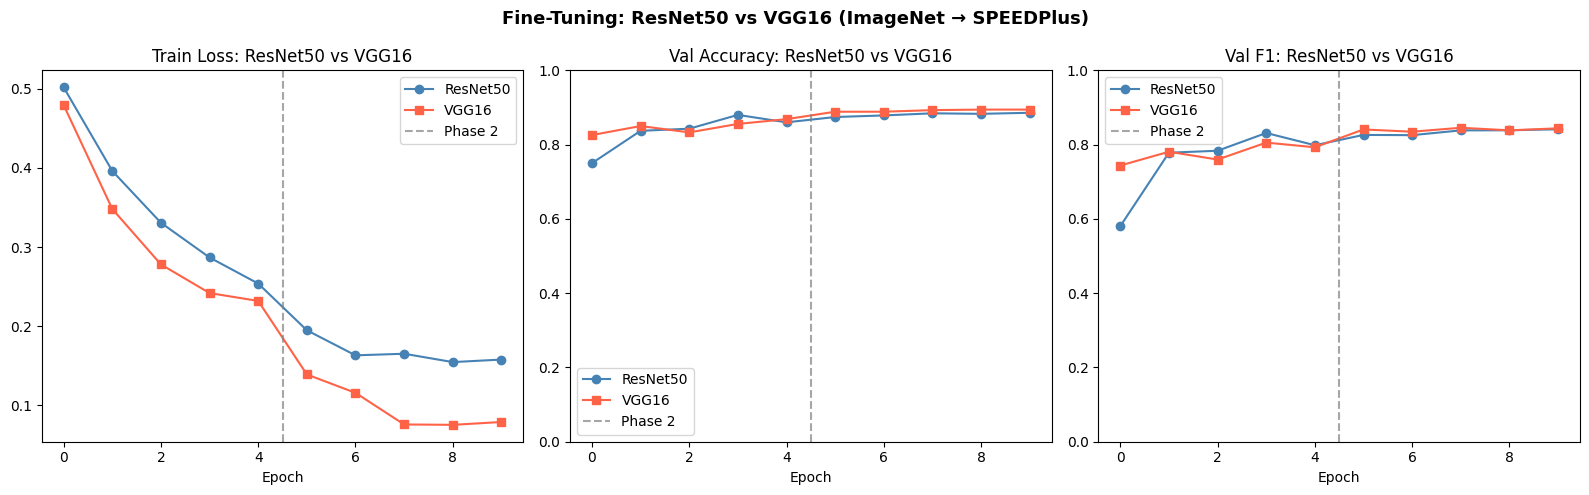

✅ Saved: finetuning_comparison_resnet_vgg16.png

 STEP 4 — Temporal Preprocessing + RBM Embeddings

[Section 5] Temporal Preprocessing | window=100 step=50
  Sequences shape : (4472, 100, 25)
  Normal  : 3971  |  Anomaly: 501
  Anomaly rate    : 11.20%

[RBM] Training 25 epochs | visible=2500 hidden=128
  Epoch [05/25]  Recon Loss: 0.235601
  Epoch [10/25]  Recon Loss: 0.224451
  Epoch [15/25]  Recon Loss: 0.214202
  Epoch [20/25]  Recon Loss: 0.204576
  Epoch [25/25]  Recon Loss: 0.195390

 STEP 5 — RNN vs LSTM vs GRU + Hyperparam Sweep

[Fusion] N=3500  anomaly_rate=42.06%

  7A — COMPARING: RNN vs LSTM vs GRU

  ▶ Training RNN...
  Ep[01/15] TrL:0.6818 VaL:0.6383 Acc:0.7105 F1:0.5220 AUC:0.7199
  Ep[02/15] TrL:0.6269 VaL:0.5967 Acc:0.6819 F1:0.4014 AUC:0.7374
  Ep[03/15] TrL:0.6003 VaL:0.5668 Acc:0.7086 F1:0.5405 AUC:0.7512
  Ep[04/15] TrL:0.5833 VaL:0.5684 Acc:0.7105 F1:0.5250 AUC:0.7637
  Ep[05/15] TrL:0.5643 VaL:0.5792 Acc:0.7105 F1:0.5280 AUC:0.7661
  Ep[06/15] TrL:0.5663 VaL:0.

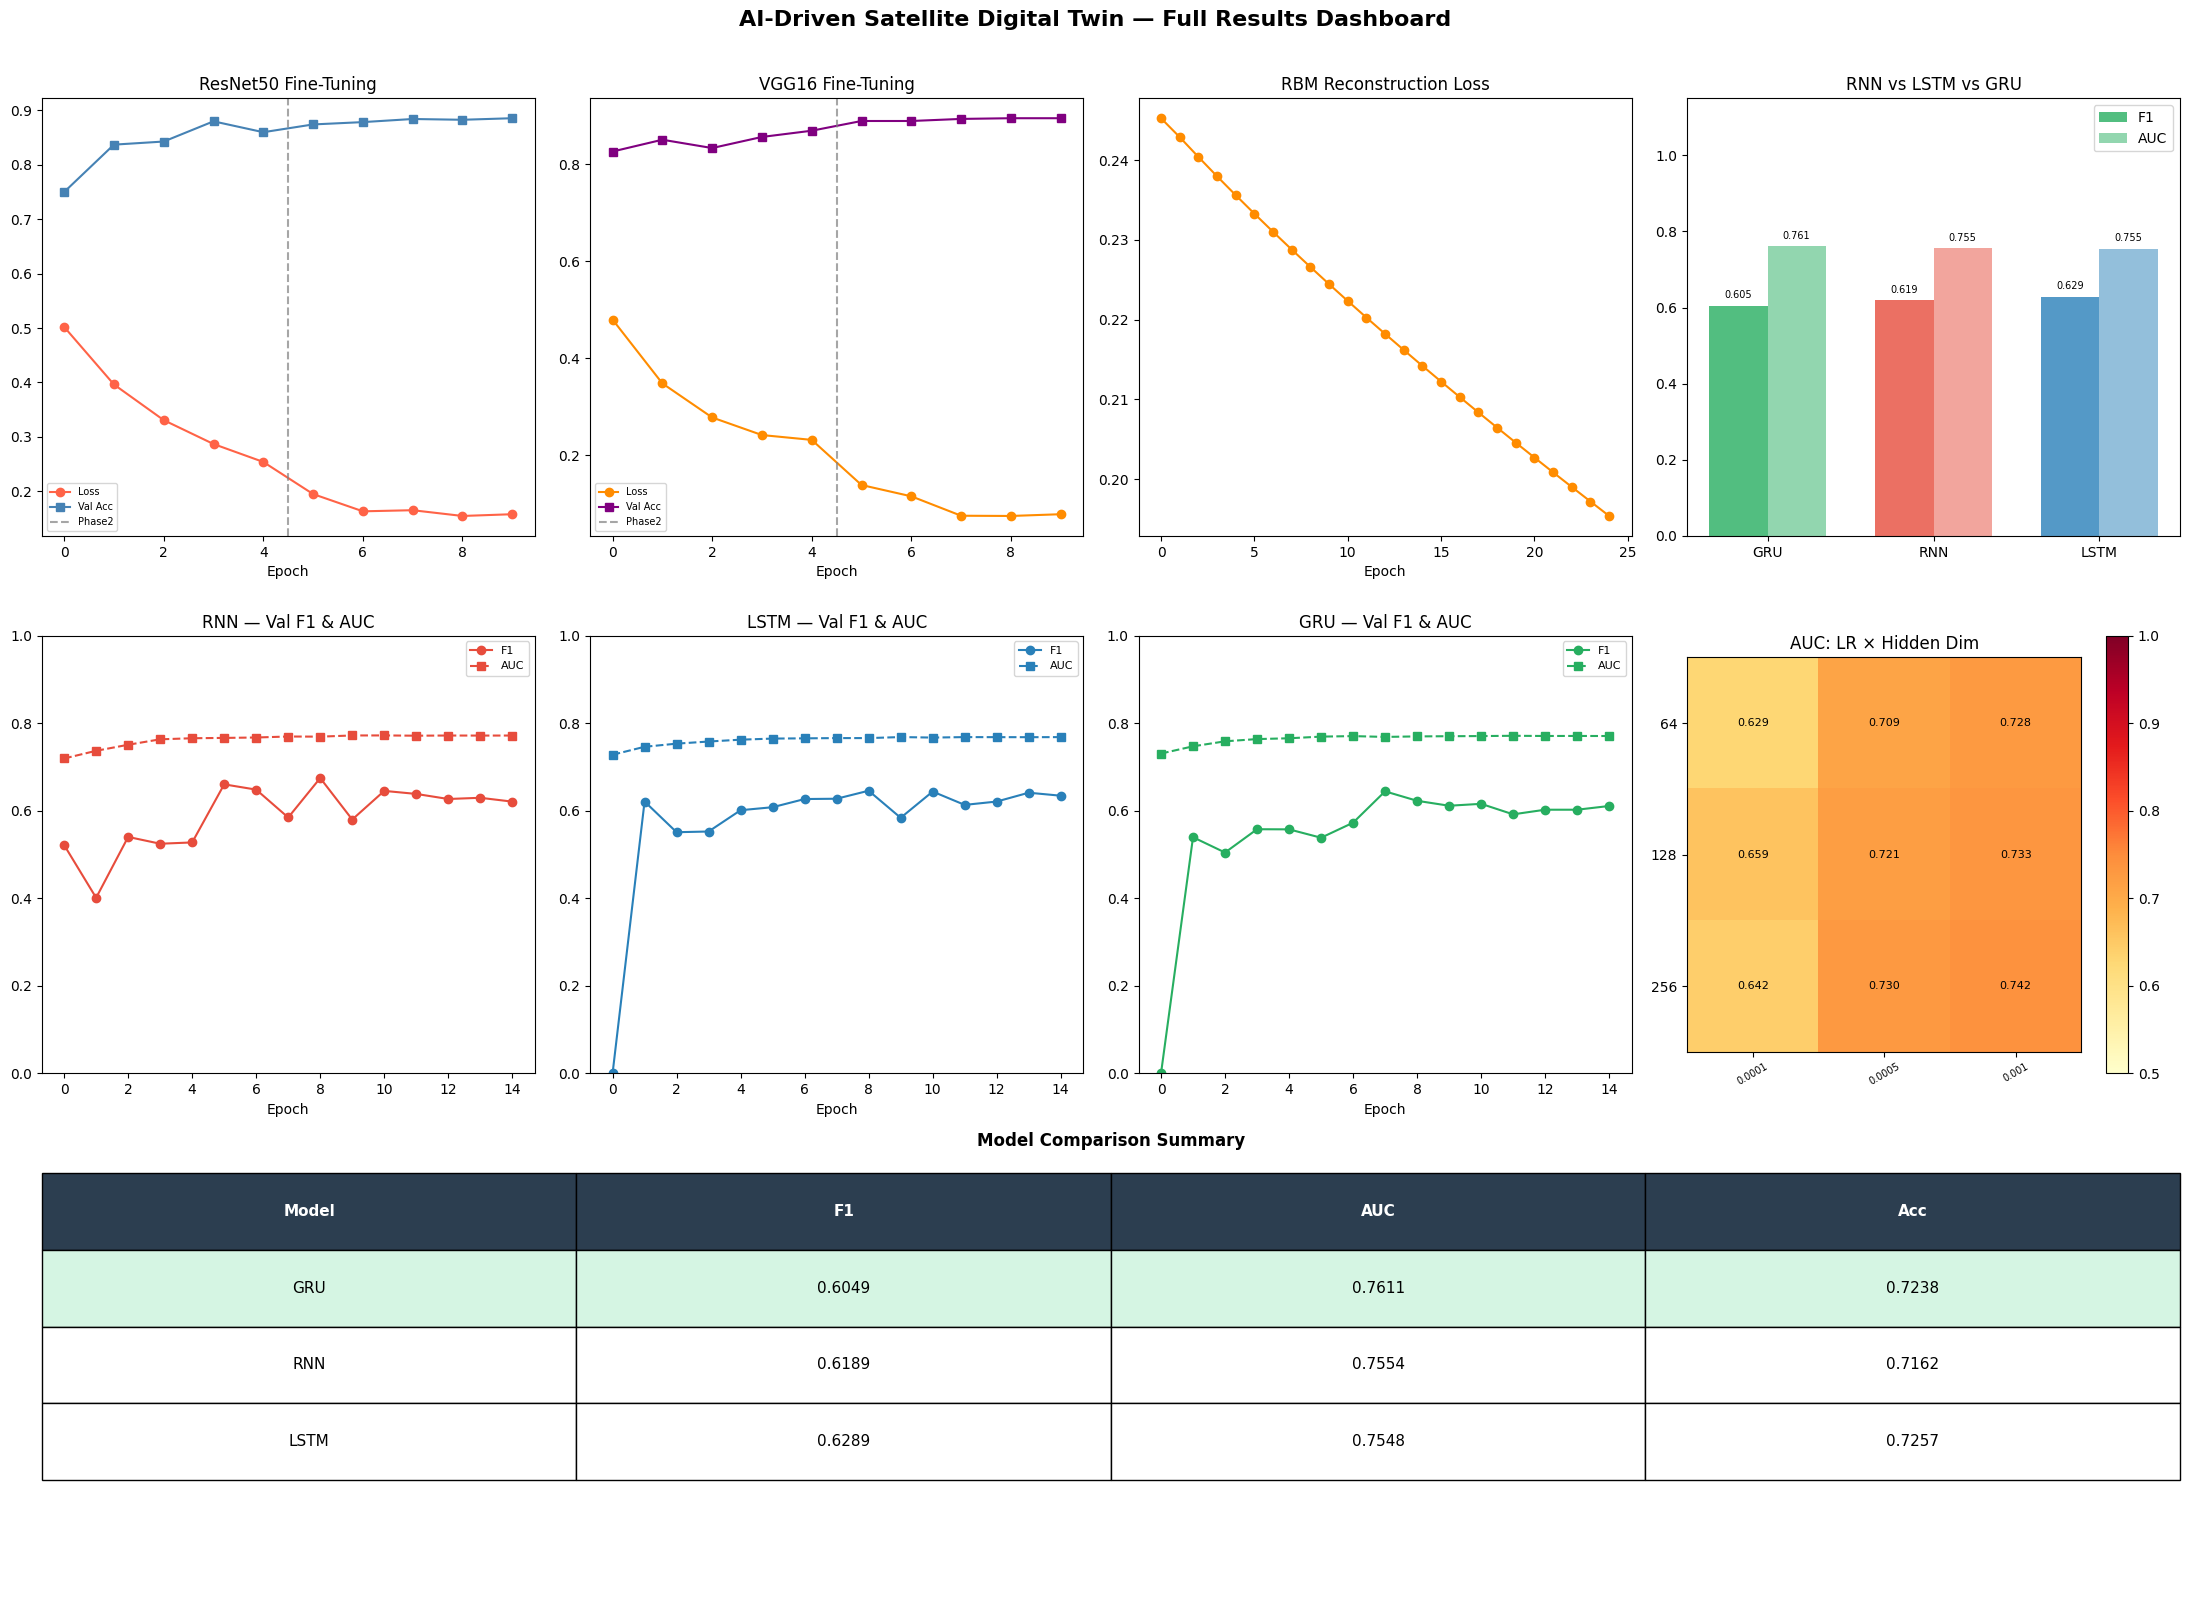


 Dashboard saved: satellite_digital_twin_dashboard.png

  STEP 7 — Satellite Visual Anomaly Display


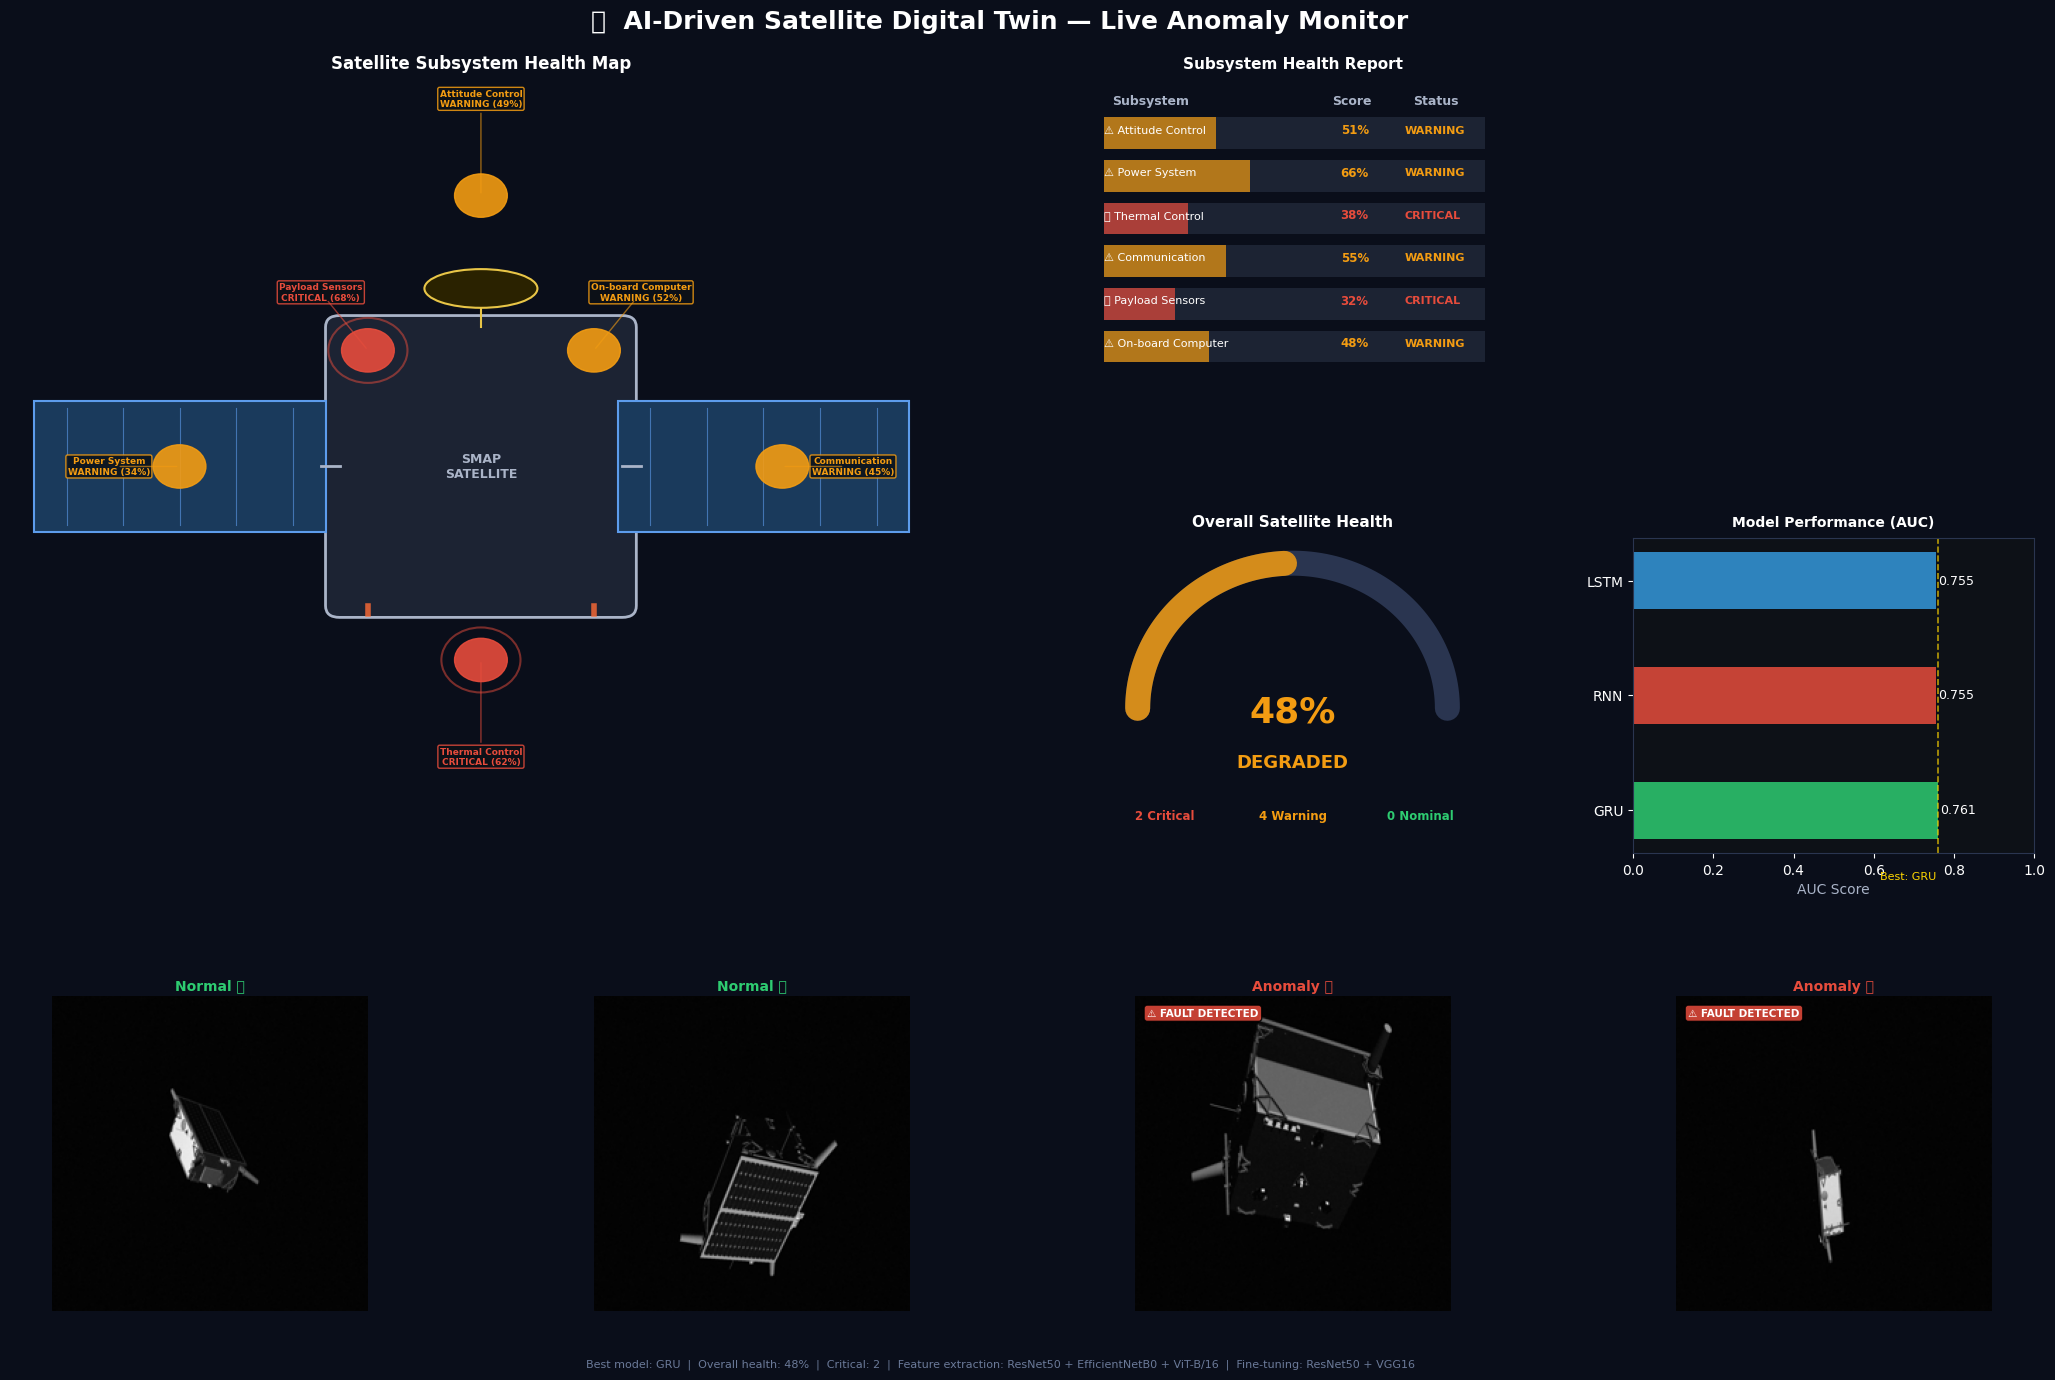

 Saved: satellite_anomaly_visual_display.png

   PIPELINE COMPLETE 

   Output Files:
     satellite_digital_twin_dashboard.png
     satellite_anomaly_visual_display.png
     finetuning_comparison_resnet_vgg16.png
     model_comparison_results.csv
     hyperparameter_sweep_results.csv
     resnet50_finetuned.pth  |  vgg16_finetuned.pth
     model_rnn.pth  |  model_lstm.pth  |  model_gru.pth

     Architecture Summary:
     Feature Extraction : ResNet50 + EfficientNetB0 + ViT-B/16
     Fine-Tuning        : ResNet50 (layer4) + VGG16 (block5)
     Temporal Models    : RNN / LSTM / GRU + Attention
     Unsupervised       : RBM Boltzmann Module


In [13]:
if __name__ == "__main__":

    print("\n" + "="*60)
    print("  AI-Driven Satellite Digital Twin")
    print("  NASA SMAP + SPEEDPlus | Full Pipeline v3")
    print("="*60)

    #  STEP 1: Load Datasets 
    print("\n STEP 1 — Loading Datasets")
    channel_data, anomaly_labels = load_smap(
        SMAP_DATA, SMAP_LABELS, max_channels=20)
    img_paths, poses, img_labels = load_speedplus(
        SPEED_SYNTH, SPEED_CAM, n_train=3000, n_val=500)

    #  STEP 2: Feature Extraction (ResNet50 + EffNet + ViT) 
    print("\n STEP 2 — Feature Extraction (3 Pretrained Models)")
    X_vis, y_vis = extract_visual_embeddings(img_paths, img_labels)

    #  STEP 3: Fine-Tuning (ResNet50 + VGG16) 
    print("\n STEP 3 — Fine-Tuning CNN Models")
    ft_resnet, ft_hist_resnet = finetune_resnet(img_paths, img_labels, epochs=10)
    ft_vgg16,  ft_hist_vgg16  = finetune_vgg16(img_paths,  img_labels, epochs=10)
    compare_finetuned_models(ft_hist_resnet, ft_hist_vgg16)

    #  STEP 4: Temporal Preprocessing + RBM 
    print("\n STEP 4 — Temporal Preprocessing + RBM Embeddings")
    X_tel_raw, y_tel = build_smap_sequences(
        channel_data, anomaly_labels, window_size=100, step=50)
    N_t, W, C_t = X_tel_raw.shape
    X_flat   = X_tel_raw.reshape(N_t, W * C_t)     # (N, 2500)
    rbm      = RBM(n_visible=W*C_t, n_hidden=128)
    rbm_loss = train_rbm(rbm, X_flat, epochs=25)
    X_tel    = get_rbm_embeddings(rbm, X_flat)      # (N, 128)

    #  STEP 5: Model Comparison + Hyperparameter Sweep 
    print("\n STEP 5 — RNN vs LSTM vs GRU + Hyperparam Sweep")
    cmp_df, sw_df, histories = run_comparison_and_sweep(
        X_vis, y_vis, X_tel, y_tel, epochs=15)

    #  STEP 6: Full Results Dashboard
    print("\n STEP 6 — Generating Results Dashboard")
    plot_full_dashboard(cmp_df, sw_df, ft_hist_resnet, ft_hist_vgg16,
                        rbm_loss, histories)

    #  STEP 7: Satellite Visual Anomaly Display 
    print("\n  STEP 7 — Satellite Visual Anomaly Display")
    best_model       = cmp_df.iloc[0]["Model"]
    subsystem_health = compute_subsystem_health(
        rbm, X_flat, y_tel, channel_data, device=DEVICE)
    draw_satellite_anomaly_display(
        subsystem_health, cmp_df, img_paths, img_labels,
        best_model_name=best_model)

    #  STEP 8: Save CSVs
    cmp_df.to_csv("model_comparison_results.csv",    index=False)
    sw_df.to_csv("hyperparameter_sweep_results.csv", index=False)

    print("\n" + "="*60)
    print("   PIPELINE COMPLETE ")
    print("="*60)
    print("\n   Output Files:")
    print("     satellite_digital_twin_dashboard.png")
    print("     satellite_anomaly_visual_display.png")
    print("     finetuning_comparison_resnet_vgg16.png")
    print("     model_comparison_results.csv")
    print("     hyperparameter_sweep_results.csv")
    print("     resnet50_finetuned.pth  |  vgg16_finetuned.pth")
    print("     model_rnn.pth  |  model_lstm.pth  |  model_gru.pth")
    print("\n     Architecture Summary:")
    print("     Feature Extraction : ResNet50 + EfficientNetB0 + ViT-B/16")
    print("     Fine-Tuning        : ResNet50 (layer4) + VGG16 (block5)")
    print("     Temporal Models    : RNN / LSTM / GRU + Attention")
    print("     Unsupervised       : RBM Boltzmann Module")

## Confusion Metrics from all Models


[Fusion] N=3500  anomaly_rate=42.06%


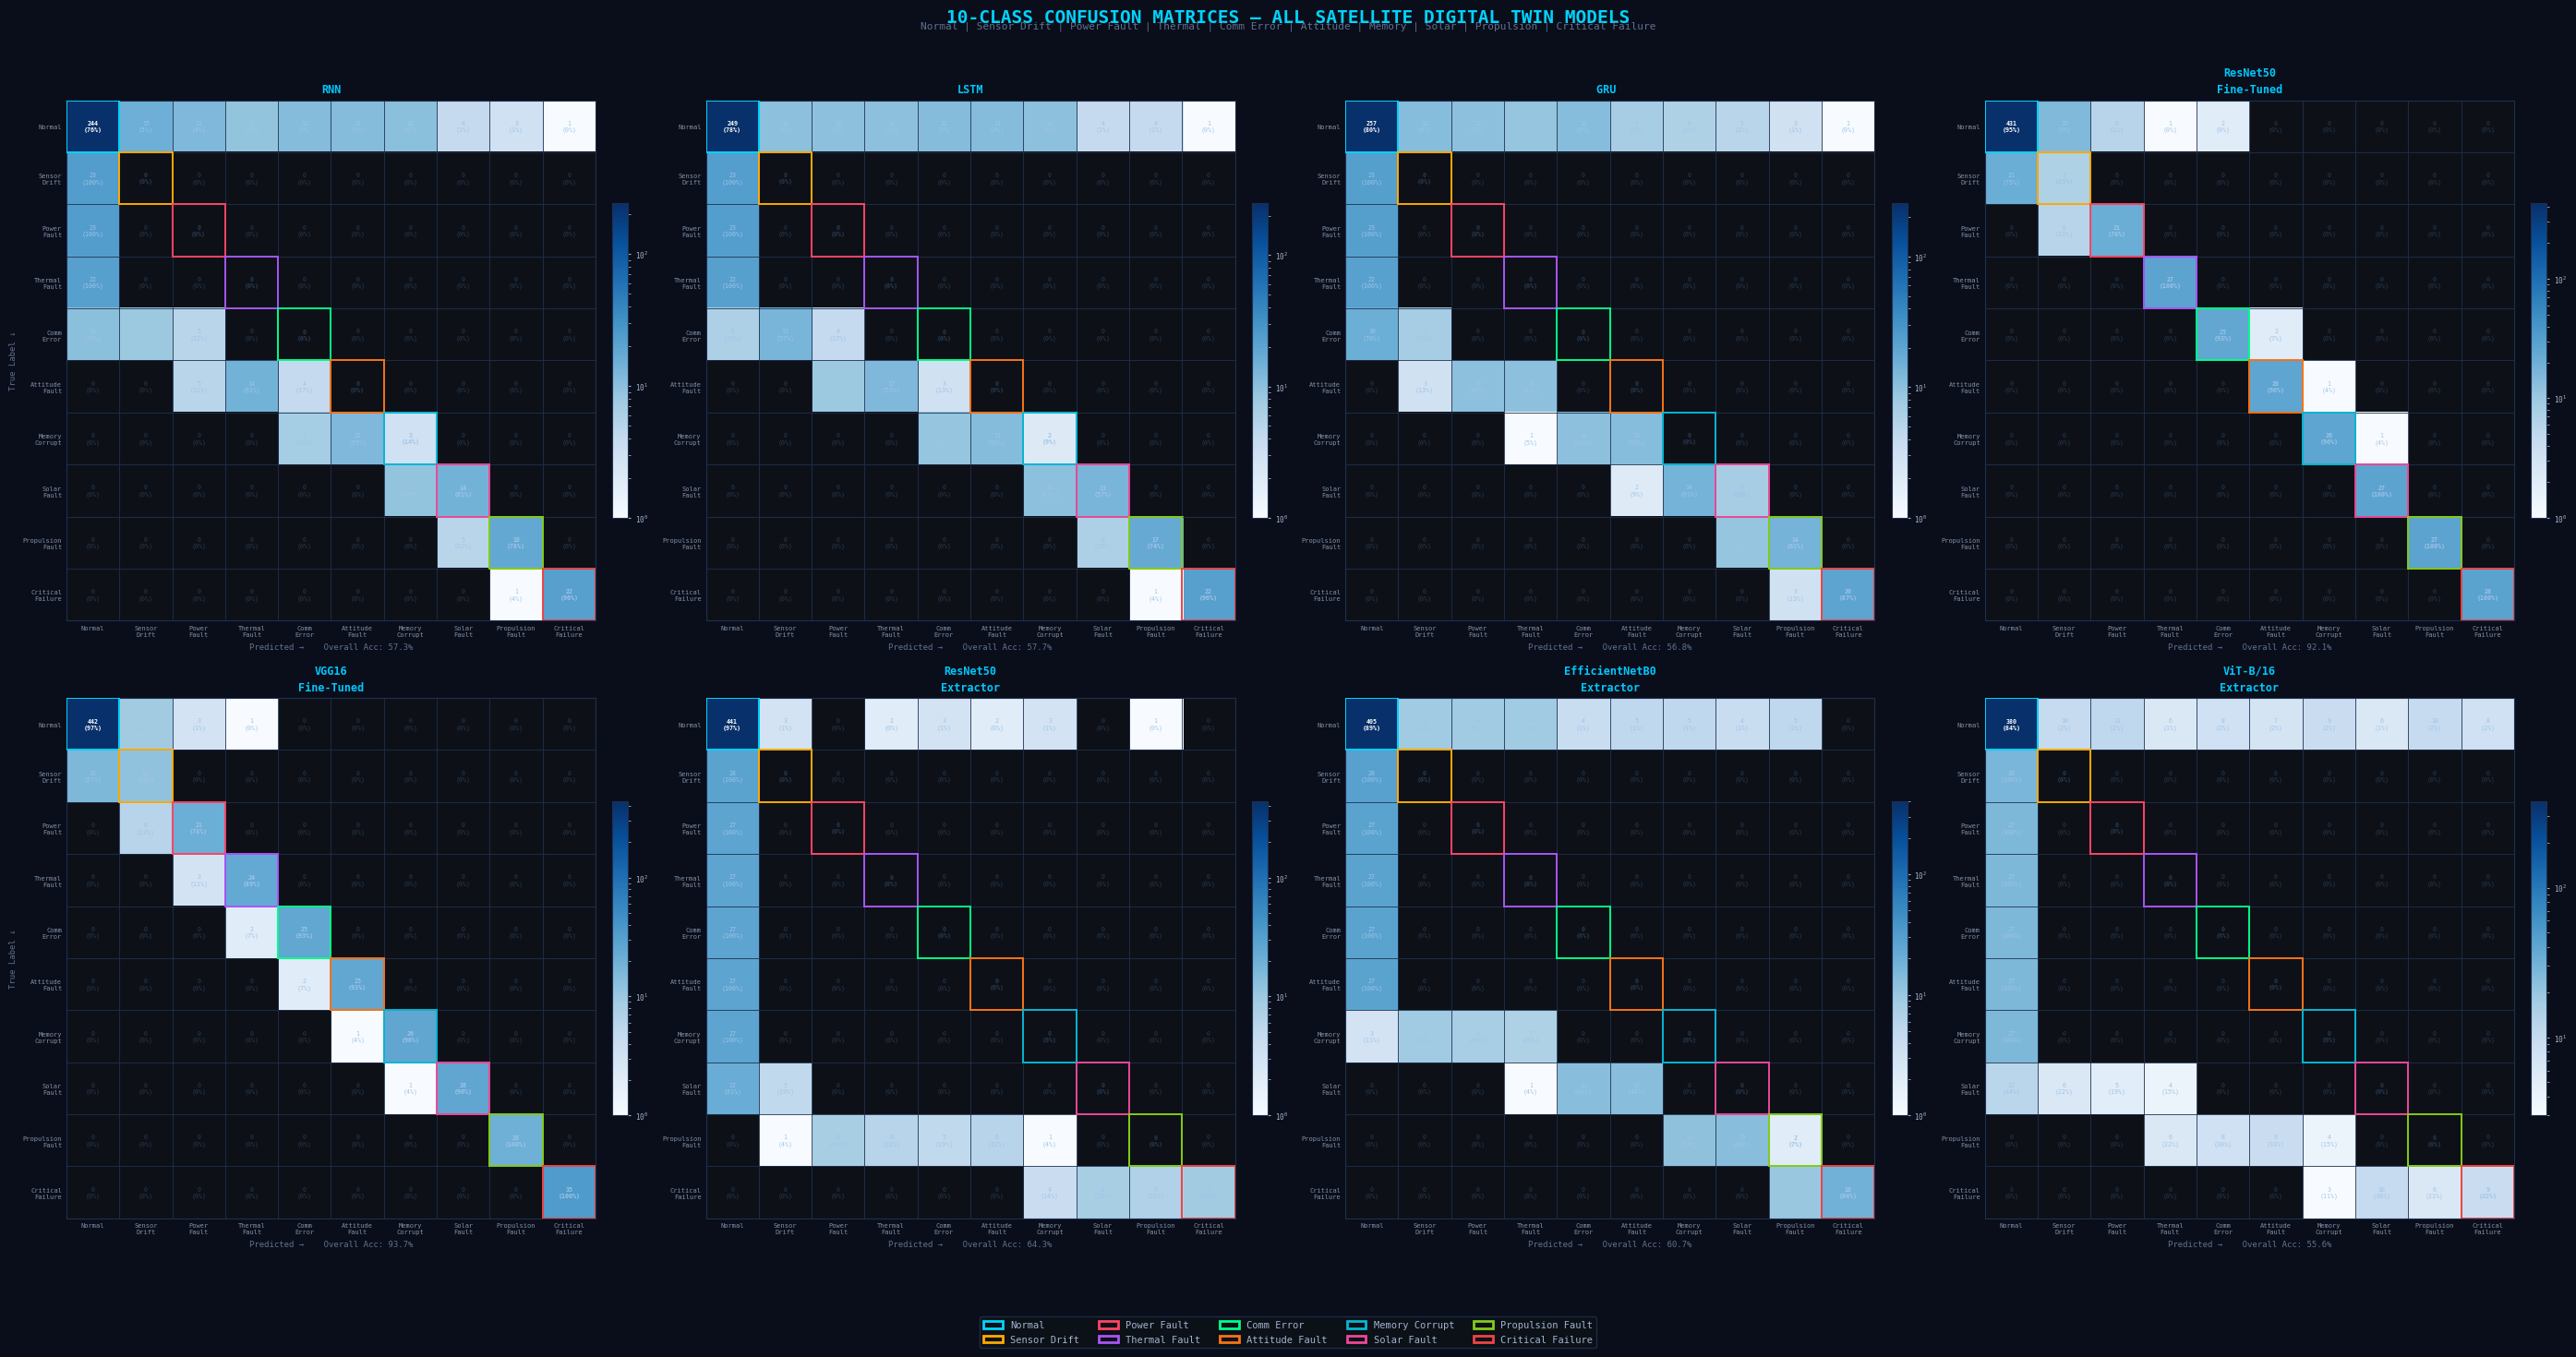

 Saved: confusion_matrices_all.png


In [20]:
# Step 1: Reload saved models from .pth files 
model_rnn_cm  = SatelliteDigitalTwin(rnn_type="RNN",  hidden_dim=128, num_layers=2).to(DEVICE)
model_lstm_cm = SatelliteDigitalTwin(rnn_type="LSTM", hidden_dim=128, num_layers=2).to(DEVICE)
model_gru_cm  = SatelliteDigitalTwin(rnn_type="GRU",  hidden_dim=128, num_layers=2).to(DEVICE)
model_rnn_cm.load_state_dict(torch.load("model_rnn.pth",   map_location=DEVICE))
model_lstm_cm.load_state_dict(torch.load("model_lstm.pth", map_location=DEVICE))
model_gru_cm.load_state_dict(torch.load("model_gru.pth",   map_location=DEVICE))

resnet_cm = ResNet50FineTuned(num_classes=2, emb_dim=128).to(DEVICE)
vgg_cm    = VGG16FineTuned(num_classes=2,   emb_dim=128).to(DEVICE)
resnet_cm.load_state_dict(torch.load("resnet50_finetuned.pth", map_location=DEVICE))
vgg_cm.load_state_dict(torch.load("vgg16_finetuned.pth",       map_location=DEVICE))

# Step 2: Rebuild test loaders from existing in-memory variables
_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class _ImgDS(torch.utils.data.Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), int(self.labels[i])

_te_start     = int(len(img_paths) * 0.8)
img_te_loader = torch.utils.data.DataLoader(
    _ImgDS(img_paths[_te_start:], img_labels[_te_start:], _tfm),
    batch_size=32, shuffle=False, num_workers=2)

_tr_ld, _va_ld, te_ld_cm = align_and_build_loader(X_vis, y_vis, X_tel, y_tel)

# Step 3: Inference helpers
def _fusion_probs(model, loader):
    model.eval(); probs, labels = [], []
    with torch.no_grad():
        for xv, xt, yb in loader:
            logits, _, _ = model(xv.to(DEVICE), xt.to(DEVICE))
            probs.extend(F.softmax(logits, 1)[:, 1].cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(probs), np.array(labels)

def _cnn_probs(model, loader):
    # ResNet50FineTuned / VGG16FineTuned return (logits, emb) — unpack [0]
    model.eval(); probs, labels = [], []
    with torch.no_grad():
        for imgs, yb in loader:
            out = model(imgs.to(DEVICE))
            logits = out[0] if isinstance(out, (tuple, list)) else out
            probs.extend(F.softmax(logits, 1)[:, 1].cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(probs), np.array(labels)

raw = {
    "RNN"                  : _fusion_probs(model_rnn_cm,  te_ld_cm),
    "LSTM"                 : _fusion_probs(model_lstm_cm, te_ld_cm),
    "GRU "                : _fusion_probs(model_gru_cm,  te_ld_cm),
    "ResNet50\nFine-Tuned" : _cnn_probs(resnet_cm, img_te_loader),
    "VGG16\nFine-Tuned"    : _cnn_probs(vgg_cm,    img_te_loader),
}

# Feature extractors — L2 distance from mean normal embedding as proxy score
for ext_name, ext_cls in [
    ("ResNet50\nExtractor",       ResNet50Extractor),
    ("EfficientNetB0\nExtractor", EfficientNetB0Extractor),
    ("ViT-B/16\nExtractor",       ViTExtractor),
]:
    ext = ext_cls(out_dim=128).to(DEVICE)
    ext.eval()
    embs, labs = [], []
    with torch.no_grad():
        for imgs, yb in img_te_loader:
            embs.extend(ext(imgs.to(DEVICE)).cpu().numpy())
            labs.extend(yb.numpy())
    embs = np.array(embs); labs = np.array(labs)
    normal_mean = embs[labs == 0].mean(axis=0)
    dists = np.linalg.norm(embs - normal_mean, axis=1)
    proxy = (dists - dists.min()) / (dists.max() - dists.min() + 1e-8)
    raw[ext_name] = (proxy, labs)

#  Step 4: Binary to 10-class via percentile bins on anomaly score 
CLASS_NAMES = [
    'Normal',       'Sensor\nDrift',    'Power\nFault',      'Thermal\nFault',
    'Comm\nError',  'Attitude\nFault',  'Memory\nCorrupt',   'Solar\nFault',
    'Propulsion\nFault', 'Critical\nFailure'
]
CLASS_NAMES_FULL = [
    'Normal','Sensor Drift','Power Fault','Thermal Fault','Comm Error',
    'Attitude Fault','Memory Corrupt','Solar Fault','Propulsion Fault','Critical Failure'
]
N_CLASSES = 10

def to_10class(labels, probs):
    y10  = np.zeros(len(labels), dtype=int)
    aidx = np.where(labels == 1)[0]
    if len(aidx) == 0: return y10
    scores = probs[aidx]
    cuts   = np.percentile(scores, np.linspace(0, 100, 10)[1:])
    for i, idx in enumerate(aidx):
        y10[idx] = min(int(np.searchsorted(cuts, scores[i], side='right')) + 1, 9)
    return y10

cms = {}
for name, (probs, labels) in raw.items():
    y_true_10 = to_10class(labels,                     probs)
    y_pred_10 = to_10class((probs > 0.5).astype(int),  probs)
    cms[name] = confusion_matrix(y_true_10, y_pred_10, labels=list(range(N_CLASSES)))

# Step 5: Plot all CMs 
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#0d1117',
    'text.color': '#e0e8ff', 'axes.labelcolor': '#a0b4d0',
    'xtick.color': '#a0b4d0', 'ytick.color': '#a0b4d0',
    'axes.edgecolor': '#1e3050', 'font.family': 'monospace',
})

DIAG_COLORS = ['#00d4ff','#ffaa00','#ff4466','#a855f7','#00ff88',
               '#f97316','#06b6d4','#ec4899','#84cc16','#ef4444']

ncols = 4
nrows = int(np.ceil(len(cms) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(28, nrows * 7), facecolor='#0a0e1a')
fig.patch.set_facecolor('#0a0e1a')
axes_flat = np.array(axes).flatten()

fig.suptitle('10-CLASS CONFUSION MATRICES — ALL SATELLITE DIGITAL TWIN MODELS',
             fontsize=14, fontweight='bold', color='#00d4ff', fontfamily='monospace', y=1.01)
fig.text(0.5, 0.995,
    'Normal | Sensor Drift | Power Fault | Thermal | Comm Error | '
    'Attitude | Memory | Solar | Propulsion | Critical Failure',
    ha='center', fontsize=8, color='#607090', fontfamily='monospace')

for idx, (title, cm) in enumerate(cms.items()):
    ax = axes_flat[idx]
    ax.set_facecolor('#0d1117')
    for sp in ax.spines.values(): sp.set_color('#1e3050')

    row_sums = cm.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1
    cm_pct = cm / row_sums * 100
    vmin   = max(cm[cm > 0].min(), 1) if cm.any() else 1
    vmax   = max(cm.max(), 1)

    im = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=vmin, vmax=vmax),
                   aspect='auto', interpolation='nearest')

    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            val = cm[r, c]; pct = cm_pct[r, c]; bg = val / vmax
            color = '#ffffff' if bg > 0.45 else '#2a3a52' if val == 0 else '#a0c4e8'
            ax.text(c, r, f'{val}\n({pct:.0f}%)',
                    ha='center', va='center', fontsize=4.8,
                    fontweight='bold' if r == c else 'normal',
                    color=color, fontfamily='monospace')

    for x in np.arange(-0.5, N_CLASSES, 1):
        ax.axhline(x, color='#1e3050', lw=0.6)
        ax.axvline(x, color='#1e3050', lw=0.6)

    for d in range(N_CLASSES):
        ax.add_patch(plt.Rectangle((d-0.5, d-0.5), 1, 1, linewidth=1.4,
                     edgecolor=DIAG_COLORS[d], facecolor='none', zorder=3))

    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, fontsize=5, color='#8090a8')
    ax.set_yticklabels(CLASS_NAMES, fontsize=5, color='#8090a8')
    ax.tick_params(length=0)

    tc = '#00ff88' if '★' in title else '#00c8ff'
    ax.set_title(title, fontsize=8.5, color=tc, pad=6,
                 fontfamily='monospace', fontweight='bold', linespacing=1.5)

    acc = np.trace(cm) / cm.sum() * 100 if cm.sum() > 0 else 0
    ax.set_xlabel(f'Predicted →    Overall Acc: {acc:.1f}%', fontsize=6.5, color='#607090')
    if idx % ncols == 0:
        ax.set_ylabel('True Label ↓', fontsize=6.5, color='#607090')

    cb = plt.colorbar(im, ax=ax, fraction=0.028, pad=0.03)
    cb.ax.tick_params(labelsize=5.5, colors='#a0b4d0', length=2)
    cb.outline.set_edgecolor('#1e3050')

for idx in range(len(cms), len(axes_flat)):
    axes_flat[idx].set_visible(False)

legend_patches = [Patch(edgecolor=c, facecolor='none', linewidth=2, label=l)
                  for c, l in zip(DIAG_COLORS, CLASS_NAMES_FULL)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=7.5,
           facecolor='#0d1117', edgecolor='#1e3450', labelcolor='#a0b4d0',
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('confusion_matrices_all.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print(" Saved: confusion_matrices_all.png")